# Model comparison — trend classification across horizons

Compares six trend classifiers on the **OFI** feature stream over the label
horizons **k ∈ {10, 20, 50, 100}**:

| tag | class | family |
|-----|-------|--------|
| `dla + ofi`         | `DLA`         | attention encoder–decoder |
| `axial + ofi`       | `AxialLOB`    | axial attention |
| `binctabl + ofi`    | `BINCTABL`    | bilinear + BiN |
| `ctabl + ofi`       | `CTABL`       | bilinear temporal attention |
| `deeplob + ofi`     | `DeepLOB`     | CNN + inception + LSTM |
| `jumpgatelob + ofi` | `JumpGateLOB` | Lévy joint diffusion-classifier |

Every model exposes `predict(batch, device) → (B, 3) logits`, so the metrics
(accuracy, macro-F1, per-class F1, confusion) are computed identically.

**Sections**
1. Setup & checkpoint registry (auto-discovered, editable)
2. Load models + build the shared per-horizon test set
3. Overall metrics (accuracy / macro-F1 / per-class F1) across horizons
4. Confusion matrices
5. Metric-vs-horizon curves
6. **Extreme conditions (jumps)** — performance on turbulent windows
7. Summary ranking

> Run from the **Penny repo root** so the `data/` cache and `checkpoints/`
> relative paths resolve.

## 1. Setup

In [16]:
import os, sys, json, glob, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as Fn
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.metrics import f1_score, confusion_matrix, recall_score
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

# --- locate the repo root and chdir into it -----------------------------------
# Jupyter kernels default their cwd to wherever the server was launched (often
# the notebook's own directory, e.g. `notebooks/`), NOT the repo root. Config
# files store paths like "data/resampled/nobitex" that `build_cache` resolves
# against the *live process cwd* — so if we only add `src/` to sys.path without
# also chdir'ing, imports succeed but data loading fails with a confusing
# "parquet not found" error. Walk up from cwd to find `pyproject.toml` and
# chdir there so every relative path in every config resolves the same way
# regardless of how this notebook was launched.
def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "src").is_dir():
            return p
    raise RuntimeError(
        f"could not find the Penny repo root (pyproject.toml + src/) above {start}"
    )


REPO = _find_repo_root(Path.cwd())
os.chdir(REPO)
sys.path.insert(0, str(REPO / "src"))
print("repo root:", REPO)

from crypto.dataset import build_datasets            # noqa: E402
from models.dla import DLA                            # noqa: E402
from models.axiallob import AxialLOB                  # noqa: E402
from models.binctabl import BINCTABL                  # noqa: E402
from models.ctabl import CTABL                        # noqa: E402
from models.deeplob import DeepLOB                    # noqa: E402
from models.jumpgatelob import JumpGateLOB            # noqa: E402
from models.tlob import TLOB            # noqa: E402

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

repo root: /Users/arshia/Projects/Personal/Penny
device: cpu


## 2. Registry & checkpoints

`MODELS` maps each tag to its class. `HORIZONS` are the label-`k` values.

`CHECKPOINTS[model][k]` is a path to a checkpoint **directory** (containing
`best.pt`) or the `best.pt` file itself. It is auto-populated by scanning
`CHECKPOINT_ROOT` and reading each run's sibling `config.json` for
`(feature_mode, label_k, symbol)` — the newest run wins. **Edit the printed dict
to point at the exact checkpoints you want.**

In [17]:
FEATURE_MODE = "ofi"
SYMBOL       = "BTCIRT"
HORIZONS     = [10, 20, 50, 100]
BATCH        = 256

# tag -> (class, checkpoint-dir prefix written by the train scripts)
MODELS = {
    #"dla":         (DLA,         "dla_"),
    #"axial":       (AxialLOB,    "axiallob_"),
    "tlob":        (TLOB,        "tlob_"),
    "binctabl":    (BINCTABL,    "binctabl_"),
    "ctabl":       (CTABL,       "ctabl_"),
    "deeplob":     (DeepLOB,     "deeplob_"),
    "jumpgatelob": (JumpGateLOB, "jumpgatelob_"),
}
LABELS = ["down", "stationary", "up"]
DISPLAY = {m: f"{m} + {FEATURE_MODE}" for m in MODELS}

# where to scan for runs (change if your checkpoints live elsewhere)
CHECKPOINT_ROOT = REPO / "checkpoints" / "nobitex" / SYMBOL

# JSON config used only to BUILD the shared test set for each horizon.
# Any model's ofi config for that k works (identical data params); jumpgatelob
# ships one per horizon.
DATA_CONFIG = "configs/crypto/nobitex/jumpgatelob/btcirt_{fm}_k{k}.json"


def _run_config(run_dir: Path) -> dict | None:
    '''Read a run's sidecar config.json (falls back to best.pt if absent).'''
    cj = run_dir / "config.json"
    if cj.exists():
        try:
            return json.loads(cj.read_text())
        except Exception:
            pass
    bp = run_dir / "best.pt"
    if bp.exists():
        try:
            return torch.load(bp, map_location="cpu", weights_only=False)["config"]
        except Exception:
            pass
    return None


def discover_checkpoints() -> dict:
    '''tag -> {k -> newest matching run dir}, matched on prefix + config.'''
    found = {m: {} for m in MODELS}
    if not CHECKPOINT_ROOT.exists():
        print(f"! CHECKPOINT_ROOT does not exist: {CHECKPOINT_ROOT}")
        return found
    for run in sorted(CHECKPOINT_ROOT.iterdir()):        # lexical == chronological
        if not run.is_dir():
            continue
        for tag, (_cls, prefix) in MODELS.items():
            if not run.name.startswith(prefix):
                continue
            cfg = _run_config(run)
            if cfg is None:
                continue
            k = cfg.get("label_k")
            if (cfg.get("feature_mode") == FEATURE_MODE
                    and cfg.get("symbol") == SYMBOL and k in HORIZONS):
                found[tag][k] = str(run)                  # newest overwrites
    return found


CHECKPOINTS = discover_checkpoints()
print("Auto-discovered checkpoints (edit below if needed):\n")
for m in MODELS:
    row = ", ".join(f"k{k}:{'✓' if k in CHECKPOINTS[m] else '—'}" for k in HORIZONS)
    print(f"  {DISPLAY[m]:<24} {row}")
CHECKPOINTS

Auto-discovered checkpoints (edit below if needed):

  tlob + ofi               k10:✓, k20:✓, k50:✓, k100:✓
  binctabl + ofi           k10:✓, k20:✓, k50:✓, k100:✓
  ctabl + ofi              k10:✓, k20:✓, k50:✓, k100:✓
  deeplob + ofi            k10:✓, k20:✓, k50:✓, k100:✓
  jumpgatelob + ofi        k10:✓, k20:✓, k50:✓, k100:✓


{'tlob': {10: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT/tlob_BTCIRT_ofi_k10',
  100: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT/tlob_BTCIRT_ofi_k100',
  20: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT/tlob_BTCIRT_ofi_k20',
  50: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT/tlob_BTCIRT_ofi_k50'},
 'binctabl': {10: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT/binctabl_BTCIRT_ofi_k10',
  100: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT/binctabl_BTCIRT_ofi_k100',
  20: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT/binctabl_BTCIRT_ofi_k20',
  50: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT/binctabl_BTCIRT_ofi_k50'},
 'ctabl': {10: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT/ctabl_BTCIRT_ofi_k10',
  100: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT/ctabl_BTCIRT_ofi_k100',
  20:

## 3. Load models & evaluate

The test set is built **once per horizon** and shared across all models, so
every model is scored on the identical windows and labels. For each window we
also record a **stress score** — the repo's own market-jump measure
(`_data_jump_flag`): the largest 1-step increment of the level-averaged feature,
in realized-volatility units. Higher ⇒ more turbulent input.

In [18]:
def load_ckpt(path: str):
    p = Path(path)
    if p.is_dir():
        p = p / "best.pt"
    return torch.load(p, map_location=DEVICE, weights_only=False)


def build_model(tag: str, ckpt: dict):
    cls, _ = MODELS[tag]
    model = cls(ckpt["config"]).to(DEVICE)
    model.load_state_dict(ckpt["model"])
    model.eval()
    return model


_DS_CACHE: dict[int, tuple] = {}


def test_set(k: int):
    '''(test_ds, y_true, stress) for horizon k — built once, then cached.'''
    if k in _DS_CACHE:
        return _DS_CACHE[k]
    cfg_path = REPO / DATA_CONFIG.format(fm=FEATURE_MODE, k=k)
    cfg = json.loads(cfg_path.read_text())
    _, _, test_ds, alpha, meta = build_datasets(cfg)
    loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False)
    ys, ss = [], []
    for b in loader:
        x = b["x"].float()                       # (B, 1, T, F)
        agg = x.squeeze(1).mean(-1)              # (B, T) level-averaged stream
        dif = agg[:, 1:] - agg[:, :-1]
        rv = dif.std(dim=1).clamp_min(1e-8)
        ss.append((dif.abs().max(dim=1).values / rv).numpy())
        ys.append(b["label"].numpy())
    y_true = np.concatenate(ys)
    stress = np.concatenate(ss)
    print(f"  k={k:<3} test windows={len(y_true):>6}  "
          f"class balance {np.bincount(y_true, minlength=3) / len(y_true)}")
    _DS_CACHE[k] = (test_ds, y_true, stress)
    return _DS_CACHE[k]


@torch.no_grad()
def evaluate(model, test_ds):
    loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False)
    yt, yp, pr = [], [], []
    for b in loader:
        logits = model.predict(b, DEVICE)
        pr.append(Fn.softmax(logits, dim=1).cpu().numpy())
        yp.append(logits.argmax(dim=1).cpu().numpy())
        yt.append(b["label"].numpy())
    return np.concatenate(yt), np.concatenate(yp), np.concatenate(pr)

In [19]:
# RESULTS[(tag, k)] = {"y_true", "y_pred", "probs", "stress"}
RESULTS: dict = {}

for k in HORIZONS:
    print(f"horizon k={k}")
    try:
        test_ds, y_true, stress = test_set(k)
    except FileNotFoundError as e:
        print(f"  ! could not build test set for k={k}: {e}")
        print(f"    (cwd is {Path.cwd()} — if this looks wrong, re-run the setup "
              f"cell; if the file is genuinely missing, run `uv run dvc pull`)")
        continue
    except Exception as e:
        print(f"  ! could not build test set for k={k}: {e}")
        continue
    for tag in MODELS:
        path = CHECKPOINTS.get(tag, {}).get(k)
        if not path or not Path(path).exists():
            print(f"  {DISPLAY[tag]:<24} — no checkpoint, skipped")
            continue
        ckpt = load_ckpt(path)
        cfg = ckpt["config"]
        if cfg.get("label_k") != k or cfg.get("feature_mode") != FEATURE_MODE:
            print(f"  {DISPLAY[tag]:<24} ! config mismatch "
                  f"(k={cfg.get('label_k')}, fm={cfg.get('feature_mode')}), skipped")
            continue
        model = build_model(tag, ckpt)
        yt, yp, pr = evaluate(model, test_ds)
        assert np.array_equal(yt, y_true), "window/label misalignment"
        RESULTS[(tag, k)] = {"y_true": yt, "y_pred": yp, "probs": pr, "stress": stress}
        acc = (yt == yp).mean()
        f1 = f1_score(yt, yp, average="macro", labels=[0, 1, 2], zero_division=0)
        print(f"  {DISPLAY[tag]:<24} acc={acc:.4f}  macro_f1={f1:.4f}")
        del model
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

print(f"\nevaluated {len(RESULTS)} (model, horizon) pairs")

2026-07-09 17:16:38.886 | INFO     | crypto.loader:build_cache:131 - building 'lob' cache from data/resampled/nobitex/BTCIRT.parquet.gz


horizon k=10


2026-07-09 17:16:39.118 | INFO     | crypto.loader:build_cache:150 -   2026-06-05 — 2127 rows
2026-07-09 17:16:39.136 | INFO     | crypto.loader:build_cache:150 -   2026-06-06 — 8334 rows
2026-07-09 17:16:39.160 | INFO     | crypto.loader:build_cache:150 -   2026-06-07 — 6828 rows
2026-07-09 17:16:39.180 | INFO     | crypto.loader:build_cache:150 -   2026-06-08 — 3792 rows
2026-07-09 17:16:39.197 | INFO     | crypto.loader:build_cache:150 -   2026-06-09 — 8568 rows
2026-07-09 17:16:39.218 | INFO     | crypto.loader:build_cache:150 -   2026-06-10 — 8566 rows
2026-07-09 17:16:39.238 | INFO     | crypto.loader:build_cache:150 -   2026-06-11 — 8623 rows
2026-07-09 17:16:39.257 | INFO     | crypto.loader:build_cache:150 -   2026-06-12 — 8620 rows
2026-07-09 17:16:39.278 | INFO     | crypto.loader:build_cache:150 -   2026-06-13 — 8168 rows
2026-07-09 17:16:39.298 | INFO     | crypto.loader:build_cache:150 -   2026-06-14 — 8118 rows
2026-07-09 17:16:39.318 | INFO     | crypto.loader:build_cac

  k=10  test windows= 15640  class balance [0.37710997 0.26496164 0.35792839]
  tlob + ofi               acc=0.6469  macro_f1=0.6463
  binctabl + ofi           acc=0.6575  macro_f1=0.6516
  ctabl + ofi              acc=0.6660  macro_f1=0.6626
  deeplob + ofi            acc=0.5858  macro_f1=0.5793


2026-07-09 17:17:07.374 | INFO     | crypto.loader:build_cache:131 - building 'lob' cache from data/resampled/nobitex/BTCIRT.parquet.gz
2026-07-09 17:17:07.439 | INFO     | crypto.loader:build_cache:150 -   2026-06-05 — 2127 rows
2026-07-09 17:17:07.458 | INFO     | crypto.loader:build_cache:150 -   2026-06-06 — 8334 rows
2026-07-09 17:17:07.489 | INFO     | crypto.loader:build_cache:150 -   2026-06-07 — 6828 rows
2026-07-09 17:17:07.510 | INFO     | crypto.loader:build_cache:150 -   2026-06-08 — 3792 rows
2026-07-09 17:17:07.528 | INFO     | crypto.loader:build_cache:150 -   2026-06-09 — 8568 rows
2026-07-09 17:17:07.561 | INFO     | crypto.loader:build_cache:150 -   2026-06-10 — 8566 rows


...

  k=50  test windows= 15600  class balance [0.39185897 0.24115385 0.36698718]
  tlob + ofi               acc=0.5732  macro_f1=0.5541
  binctabl + ofi           acc=0.5935  macro_f1=0.5630
  ctabl + ofi              acc=0.6106  macro_f1=0.5947
  deeplob + ofi            acc=0.5214  macro_f1=0.4984


2026-07-09 17:18:04.322 | INFO     | crypto.loader:build_cache:131 - building 'lob' cache from data/resampled/nobitex/BTCIRT.parquet.gz
2026-07-09 17:18:04.384 | INFO     | crypto.loader:build_cache:150 -   2026-06-05 — 2127 rows
2026-07-09 17:18:04.402 | INFO     | crypto.loader:build_cache:150 -   2026-06-06 — 8334 rows
2026-07-09 17:18:04.424 | INFO     | crypto.loader:build_cache:150 -   2026-06-07 — 6828 rows
2026-07-09 17:18:04.449 | INFO     | crypto.loader:build_cache:150 -   2026-06-08 — 3792 rows
2026-07-09 17:18:04.468 | INFO     | crypto.loader:build_cache:150 -   2026-06-09 — 8568 rows
2026-07-09 17:18:04.494 | INFO     | crypto.loader:build_cache:150 -   2026-06-10 — 8566 rows
2026-07-09 17:18:04.516 | INFO     | crypto.loader:build_cache:150 -   2026-06-11 — 8623 rows


  jumpgatelob + ofi        acc=0.5944  macro_f1=0.5694
horizon k=100


2026-07-09 17:18:04.553 | INFO     | crypto.loader:build_cache:150 -   2026-06-12 — 8620 rows
2026-07-09 17:18:04.574 | INFO     | crypto.loader:build_cache:150 -   2026-06-13 — 8168 rows
2026-07-09 17:18:04.596 | INFO     | crypto.loader:build_cache:150 -   2026-06-14 — 8118 rows
2026-07-09 17:18:04.617 | INFO     | crypto.loader:build_cache:150 -   2026-06-15 — 8258 rows
2026-07-09 17:18:04.638 | INFO     | crypto.loader:build_cache:150 -   2026-06-16 — 8459 rows
2026-07-09 17:18:04.660 | INFO     | crypto.loader:build_cache:150 -   2026-06-17 — 8495 rows
2026-07-09 17:18:04.682 | INFO     | crypto.loader:build_cache:150 -   2026-06-18 — 7765 rows
2026-07-09 17:18:04.803 | INFO     | crypto.loader:build_cache:172 - cache 'lob' built: 104,721 rows → data/cache/nobitex/BTCIRT/k100/BTCIRT_n20_ofi_roll2000_lob.feat.npy
2026-07-09 17:18:05.550 | INFO     | crypto.dataset:build_datasets:85 - windows — train:72539 val:15431 test:15550


  k=100 test windows= 15550  class balance [0.38109325 0.22482315 0.3940836 ]
  tlob + ofi               acc=0.5720  macro_f1=0.5571
  binctabl + ofi           acc=0.5736  macro_f1=0.5384
  ctabl + ofi              acc=0.5994  macro_f1=0.5693
  deeplob + ofi            acc=0.5728  macro_f1=0.5360
  jumpgatelob + ofi        acc=0.5891  macro_f1=0.5507

evaluated 20 (model, horizon) pairs


## 4. Overall metrics

In [20]:
def metrics_row(yt, yp):
    per_f1 = f1_score(yt, yp, average=None, labels=[0, 1, 2], zero_division=0)
    return {
        "accuracy": (yt == yp).mean(),
        "macro_f1": f1_score(yt, yp, average="macro", labels=[0, 1, 2], zero_division=0),
        "f1_down": per_f1[0],
        "f1_stat": per_f1[1],
        "f1_up": per_f1[2],
    }


rows = []
for (tag, k), r in RESULTS.items():
    rows.append({"model": DISPLAY[tag], "k": k, **metrics_row(r["y_true"], r["y_pred"])})

metrics_df = pd.DataFrame(rows).sort_values(["k", "model"]).reset_index(drop=True)
metrics_df

,model,k,accuracy,macro_f1,f1_down,f1_stat,f1_up
0,binctabl + ofi,10,0.6575,0.6516,0.7037,0.5632,0.6879
1,ctabl + ofi,10,0.6660,0.6626,0.7089,0.5790,0.7000
2,deeplob + ofi,10,0.5858,0.5793,0.6347,0.5413,0.5618
3,jumpgatelob + ofi,10,0.6666,0.6600,0.7046,0.5718,0.7037
4,tlob + ofi,10,0.6469,0.6463,0.6826,0.5774,0.6791
5,binctabl + ofi,20,0.6179,0.6007,0.6778,0.4514,0.6729
6,ctabl + ofi,20,0.6197,0.6106,0.6781,0.4747,0.6791
7,deeplob + ofi,20,0.5468,0.5437,0.6001,0.4512,0.5799
8,jumpgatelob + ofi,20,0.6117,0.5989,0.6672,0.4535,0.6760
9,tlob + ofi,20,0.6014,0.5653,0.6710,0.3596,0.6654


In [21]:
# accuracy & macro-F1 pivots (rows = model, cols = horizon)
if not metrics_df.empty:
    order = [DISPLAY[m] for m in MODELS if DISPLAY[m] in set(metrics_df["model"])]
    for metric in ["accuracy", "macro_f1"]:
        piv = metrics_df.pivot(index="model", columns="k", values=metric).reindex(order)
        print(f"\n=== {metric} (rows=model, cols=horizon k) ===")
        display(piv.style.background_gradient(cmap="YlGn", axis=None).format("{:.4f}"))


=== accuracy (rows=model, cols=horizon k) ===


k,10,20,50,100
model,,,,
tlob + ofi,0.6469,0.6014,0.5732,0.5720
binctabl + ofi,0.6575,0.6179,0.5935,0.5736
ctabl + ofi,0.6660,0.6197,0.6106,0.5994
deeplob + ofi,0.5858,0.5468,0.5214,0.5728
jumpgatelob + ofi,0.6666,0.6117,0.5944,0.5891



=== macro_f1 (rows=model, cols=horizon k) ===


k,10,20,50,100
model,,,,
tlob + ofi,0.6463,0.5653,0.5541,0.5571
binctabl + ofi,0.6516,0.6007,0.5630,0.5384
ctabl + ofi,0.6626,0.6106,0.5947,0.5693
deeplob + ofi,0.5793,0.5437,0.4984,0.5360
jumpgatelob + ofi,0.6600,0.5989,0.5694,0.5507


## 5. Confusion matrices

Row-normalized (recall per true class). One row of panels per horizon.

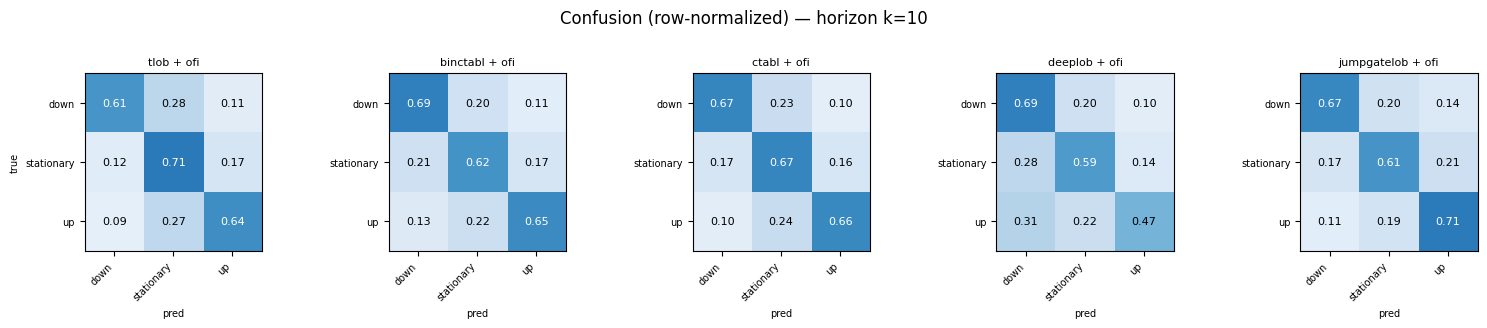

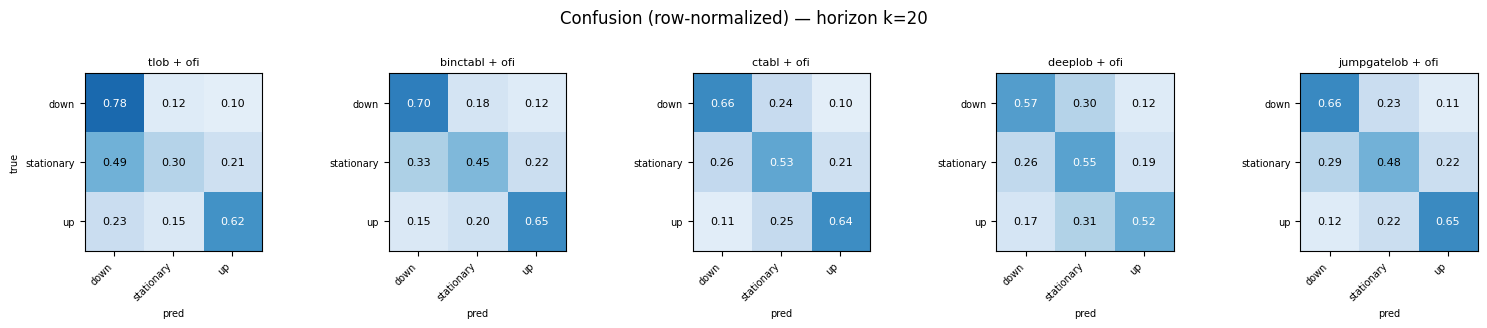

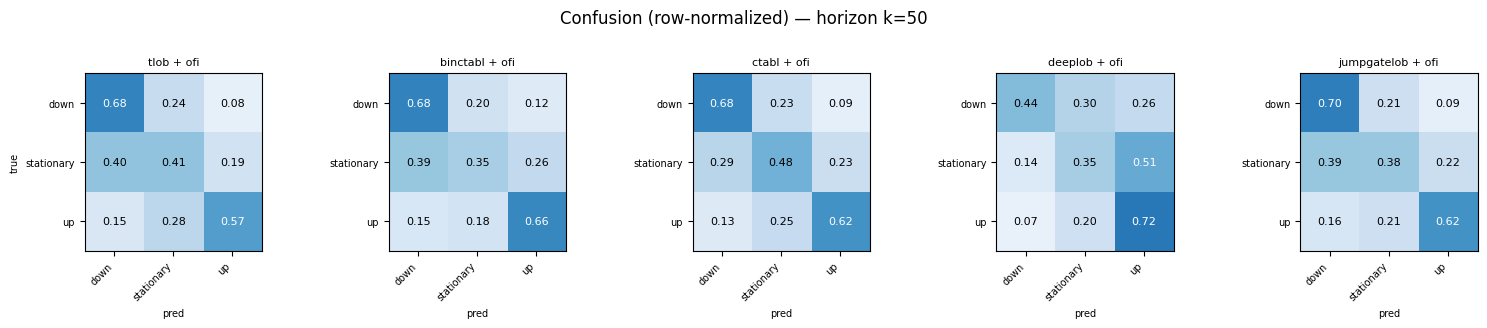

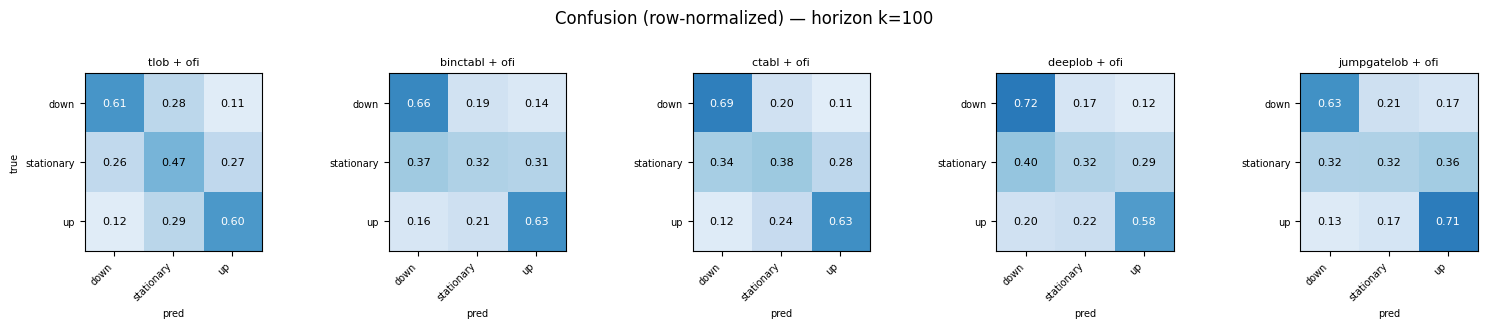

In [22]:
def plot_confusions(k):
    tags = [t for t in MODELS if (t, k) in RESULTS]
    if not tags:
        return
    fig, axes = plt.subplots(1, len(tags), figsize=(3.1 * len(tags), 3.0), squeeze=False)
    for ax, tag in zip(axes[0], tags):
        r = RESULTS[(tag, k)]
        cm = confusion_matrix(r["y_true"], r["y_pred"], labels=[0, 1, 2]).astype(float)
        cmn = cm / cm.sum(1, keepdims=True).clip(min=1)
        im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
        for i in range(3):
            for j in range(3):
                ax.text(j, i, f"{cmn[i, j]:.2f}", ha="center", va="center",
                        color="white" if cmn[i, j] > 0.5 else "black", fontsize=8)
        ax.set_xticks(range(3), LABELS, rotation=45, ha="right", fontsize=7)
        ax.set_yticks(range(3), LABELS, fontsize=7)
        ax.set_title(DISPLAY[tag], fontsize=8)
        ax.set_xlabel("pred", fontsize=7)
    axes[0][0].set_ylabel("true", fontsize=7)
    fig.suptitle(f"Confusion (row-normalized) — horizon k={k}", y=1.04)
    fig.tight_layout()
    plt.show()


for k in HORIZONS:
    plot_confusions(k)

## 6. Metric vs horizon

How each model's accuracy and macro-F1 evolve as the prediction horizon grows.

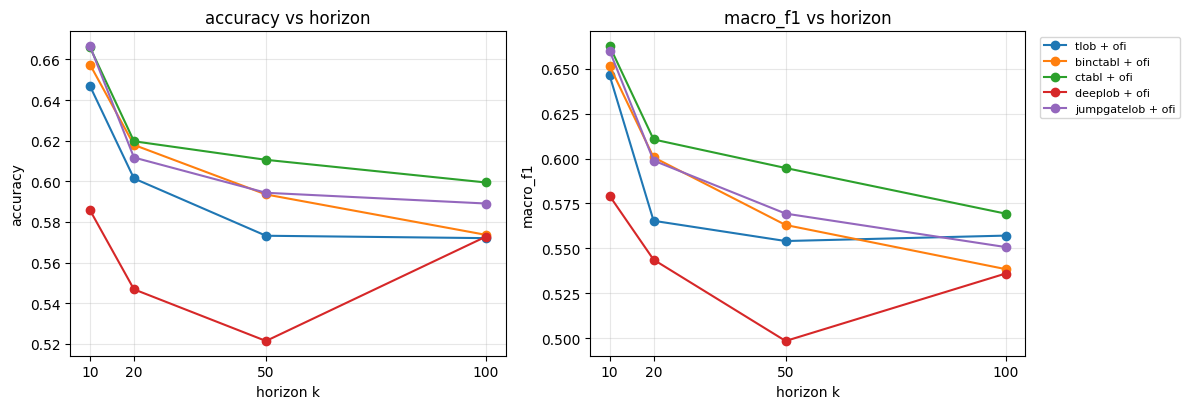

In [23]:
if not metrics_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    cmap = plt.get_cmap("tab10")
    present = [m for m in MODELS if DISPLAY[m] in set(metrics_df["model"])]
    for metric, ax in zip(["accuracy", "macro_f1"], axes):
        for i, tag in enumerate(present):
            sub = metrics_df[metrics_df["model"] == DISPLAY[tag]].sort_values("k")
            ax.plot(sub["k"], sub[metric], "o-", color=cmap(i % 10), label=DISPLAY[tag])
        ax.set_xlabel("horizon k")
        ax.set_ylabel(metric)
        ax.set_title(f"{metric} vs horizon")
        ax.set_xticks(HORIZONS)
        ax.grid(alpha=0.3)
    axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.tight_layout()
    plt.show()

## 7. Extreme conditions (jumps)

Windows are split by their **stress score** (RV-normalized max increment). We
compare performance on **calm** vs **extreme** windows, where *extreme* = the top
`EXTREME_Q` quantile of stress **within each horizon** (guarantees non-empty
buckets). A large `Δ = calm − extreme` means a model degrades under turbulence;
a small Δ means it is jump-robust.

In [24]:
EXTREME_Q = 0.90   # top 10% most turbulent windows = "extreme"

def split_metrics(r, thr):
    st = r["stress"]
    calm, extr = st <= thr, st > thr
    out = {}
    for name, mask in [("calm", calm), ("extreme", extr)]:
        if mask.sum() == 0:
            out[name] = {"n": 0, "accuracy": np.nan, "macro_f1": np.nan}
            continue
        yt, yp = r["y_true"][mask], r["y_pred"][mask]
        out[name] = {
            "n": int(mask.sum()),
            "accuracy": (yt == yp).mean(),
            "macro_f1": f1_score(yt, yp, average="macro", labels=[0, 1, 2], zero_division=0),
        }
    return out


rows = []
for (tag, k), r in RESULTS.items():
    thr = np.quantile(r["stress"], EXTREME_Q)
    s = split_metrics(r, thr)
    rows.append({
        "model": DISPLAY[tag], "k": k,
        "acc_calm": s["calm"]["accuracy"], "acc_extreme": s["extreme"]["accuracy"],
        "f1_calm": s["calm"]["macro_f1"], "f1_extreme": s["extreme"]["macro_f1"],
        "f1_drop": s["calm"]["macro_f1"] - s["extreme"]["macro_f1"],
        "n_extreme": s["extreme"]["n"],
    })
extreme_df = pd.DataFrame(rows).sort_values(["k", "model"]).reset_index(drop=True)
extreme_df

,model,k,acc_calm,acc_extreme,f1_calm,f1_extreme,f1_drop,n_extreme
0,binctabl + ofi,10,0.6584,0.6490,0.6519,0.6459,0.0060,1564
1,ctabl + ofi,10,0.6672,0.6547,0.6636,0.6524,0.0112,1564
2,deeplob + ofi,10,0.5882,0.5646,0.5814,0.5557,0.0257,1564
3,jumpgatelob + ofi,10,0.6655,0.6765,0.6584,0.6739,-0.0155,1564
4,tlob + ofi,10,0.6467,0.6490,0.6460,0.6490,-0.0030,1564
5,binctabl + ofi,20,0.6175,0.6219,0.5967,0.6215,-0.0248,1563
6,ctabl + ofi,20,0.6186,0.6296,0.6076,0.6292,-0.0215,1563
7,deeplob + ofi,20,0.5494,0.5240,0.5449,0.5210,0.0240,1563
8,jumpgatelob + ofi,20,0.6077,0.6481,0.5926,0.6471,-0.0545,1563
9,tlob + ofi,20,0.5999,0.6148,0.5588,0.6051,-0.0463,1563


In [25]:
# macro-F1 drop under stress (rows=model, cols=horizon) — lower is more robust
if not extreme_df.empty:
    order = [DISPLAY[m] for m in MODELS if DISPLAY[m] in set(extreme_df["model"])]
    piv = extreme_df.pivot(index="model", columns="k", values="f1_drop").reindex(order)
    print("=== macro-F1 drop (calm − extreme); lower = more jump-robust ===")
    display(piv.style.background_gradient(cmap="Reds", axis=None).format("{:.4f}"))

=== macro-F1 drop (calm − extreme); lower = more jump-robust ===


k,10,20,50,100
model,,,,
tlob + ofi,-0.0030,-0.0463,-0.0280,-0.1079
binctabl + ofi,0.0060,-0.0248,-0.0066,0.0024
ctabl + ofi,0.0112,-0.0215,0.0403,-0.0362
deeplob + ofi,0.0257,0.0240,-0.0429,-0.0222
jumpgatelob + ofi,-0.0155,-0.0545,-0.0349,-0.0983


### Accuracy vs stress decile

Windows binned into stress deciles; per-model accuracy in each bin. The right side of each panel is the turbulent regime.

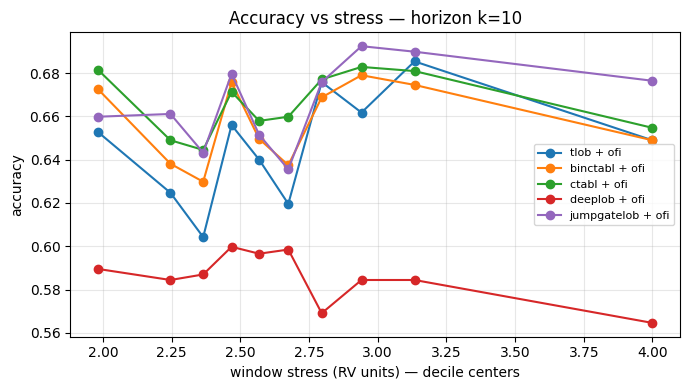

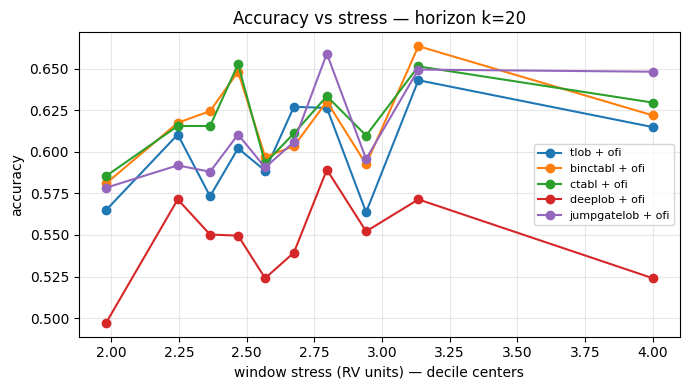

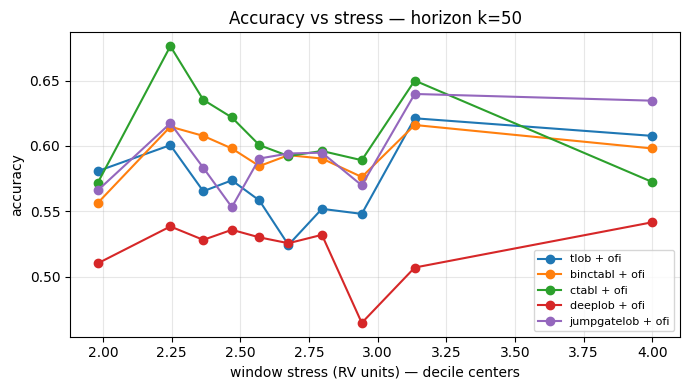

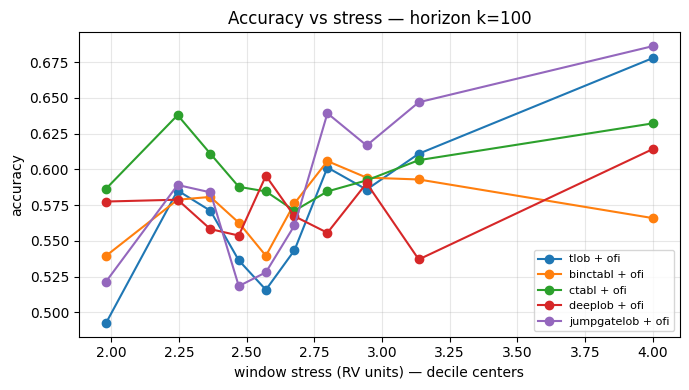

In [26]:
def plot_stress_curves(k, n_bins=10):
    tags = [t for t in MODELS if (t, k) in RESULTS]
    if not tags:
        return None
    stress = RESULTS[(tags[0], k)]["stress"]
    edges = np.quantile(stress, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    centers = 0.5 * (edges[:-1] + edges[1:])
    cmap = plt.get_cmap("tab10")
    fig, ax = plt.subplots(figsize=(7, 4))
    for i, tag in enumerate(tags):
        r = RESULTS[(tag, k)]
        correct = (r["y_true"] == r["y_pred"]).astype(float)
        idx = np.clip(np.digitize(r["stress"], edges) - 1, 0, n_bins - 1)
        acc = [correct[idx == b].mean() if (idx == b).any() else np.nan
               for b in range(n_bins)]
        ax.plot(centers, acc, "o-", color=cmap(i % 10), label=DISPLAY[tag])
    ax.set_xlabel("window stress (RV units) — decile centers")
    ax.set_ylabel("accuracy")
    ax.set_title(f"Accuracy vs stress — horizon k={k}")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


for k in HORIZONS:
    plot_stress_curves(k)

### Catching the big moves

In the extreme bucket, per-class **recall** for `down` and `up` — does the model still flag large directional moves when they happen?

In [27]:
rows = []
for (tag, k), r in RESULTS.items():
    thr = np.quantile(r["stress"], EXTREME_Q)
    mask = r["stress"] > thr
    if mask.sum() == 0:
        continue
    yt, yp = r["y_true"][mask], r["y_pred"][mask]
    rec = recall_score(yt, yp, average=None, labels=[0, 1, 2], zero_division=0)
    rows.append({"model": DISPLAY[tag], "k": k,
                 "recall_down": rec[0], "recall_up": rec[2]})
recall_df = pd.DataFrame(rows).sort_values(["k", "model"]).reset_index(drop=True)
recall_df

,model,k,recall_down,recall_up
0,binctabl + ofi,10,0.6886,0.5572
1,ctabl + ofi,10,0.6801,0.5789
2,deeplob + ofi,10,0.6481,0.3721
3,jumpgatelob + ofi,10,0.6582,0.6788
4,tlob + ofi,10,0.6263,0.5989
5,binctabl + ofi,20,0.6829,0.5745
6,ctabl + ofi,20,0.6901,0.5745
7,deeplob + ofi,20,0.5784,0.3752
8,jumpgatelob + ofi,20,0.6703,0.6750
9,tlob + ofi,20,0.7892,0.5725


## 8. Summary ranking

Mean macro-F1 across horizons (overall, calm, extreme). Higher is better; `robustness` = extreme / overall.

In [28]:
if RESULTS:
    agg = metrics_df.groupby("model")["macro_f1"].mean().rename("macro_f1_mean")
    ex = extreme_df.groupby("model")[["f1_calm", "f1_extreme"]].mean()
    summary = pd.concat([agg, ex], axis=1)
    summary["robustness"] = summary["f1_extreme"] / summary["f1_calm"].clip(lower=1e-9)
    summary = summary.sort_values("macro_f1_mean", ascending=False)
    display(summary.style.background_gradient(cmap="YlGn",
            subset=["macro_f1_mean", "f1_calm", "f1_extreme"]).format("{:.4f}"))
else:
    print("No results — populate CHECKPOINTS in section 2 and re-run.")

,macro_f1_mean,f1_calm,f1_extreme,robustness
model,,,,
ctabl + ofi,0.6093,0.6090,0.6106,1.0026
jumpgatelob + ofi,0.5947,0.5894,0.6402,1.0862
binctabl + ofi,0.5884,0.5876,0.5933,1.0098
tlob + ofi,0.5807,0.5756,0.6219,1.0805
deeplob + ofi,0.5393,0.5384,0.5422,1.0072
